# `MissingConeDataset` – Visual Sanity Check

For each sampled item `(carved_x, x, beta_int, alpha_int, slice_type)` display three panels side by side and show the slice_type metadata:
1. **x** – target slice (alpha-rotated, existing missing cone now at alpha)
2. **carved_x** – conditioning slice (x with a second Fourier cone removed at beta)
3. **log|FFT(carved_x)|** – Fourier magnitude with a double-headed arrow marking the carved-cone direction beta


In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch

sys.path.insert(0, '/myhome/sdate')
sys.path.insert(0, '/myhome/astra-torch')
sys.path.insert(0, '/myhome/chip-project')

from ladiff.datasets import MissingConeDataset
import lovely_tensors as lt
lt.monkey_patch()

print("Imports OK")
print(f"PyTorch {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")

zarr not installed
Imports OK
PyTorch 2.8.0+cu128  |  CUDA: True


In [2]:
# ── Configuration ─────────────────────────────────────────────────────────
FILE_IDX       = 1
DATA_PATH      = Path(f'/myhome/data/sdate/shared/compression_paper/file_{FILE_IDX}_extracted/reconstruction/la_fourier_{FILE_IDX}.npy')
# ── Saved volume paths (output of Large_LA_Dataset) ───────────────────────
RECON_PATH = Path(f'/myhome/data/sdate/shared/compression_paper/file_{FILE_IDX}_extracted/reconstruction')
GT_FBP_PATH  = RECON_PATH / f'gt_fbp_{FILE_IDX}.npy'
NORM_JSON    = RECON_PATH / f'la_fourier_{FILE_IDX}_norm.json'


# RECON_PATH = Path("/myhome/data/sdate/shared/em_data_npy/neuron")
# DATA_PATH = RECON_PATH / f'synapse-bin4-5i-demo.npy'
# GT_FBP_PATH = RECON_PATH / f'synapse-bin4-5i-demo.npy'
# NORM_JSON    = RECON_PATH / f'synapse-bin4-5i-demo_norm.json'

# RECON_PATH = Path("/myhome/data/sdate/shared/em_data_npy/HIV/demo_data/tomograms")
# DATA_PATH = RECON_PATH / f'TS01-wbp.npy'
# GT_FBP_PATH = RECON_PATH / f'TS01-wbp.npy'
# NORM_JSON    = RECON_PATH / f'TS01-wbp_norm.json'

CONE_WIDTH_DEG = 72.0   # (1 - 0.6) * 180  — change to match your acquisition
N_SAMPLES      = 10      # how many dataset items to visualise
SEED           = 0
GAMMA_CORRECTION_DEG = -6.0  # set to non-zero to correct for non-canonical missing cone orientation

print(f"DATA_PATH      : {DATA_PATH}")
print(f"CONE_WIDTH_DEG : {CONE_WIDTH_DEG}°")

DATA_PATH      : /myhome/data/sdate/shared/compression_paper/file_1_extracted/reconstruction/la_fourier_1.npy
CONE_WIDTH_DEG : 72.0°


In [3]:
import sys, importlib, json, time


# ── Normalization from sidecar JSON ───────────────────────────────────────
with open(NORM_JSON) as f:
    norm_cfg = json.load(f)

norm_min = float(norm_cfg['norm_min'])
norm_max = float(norm_cfg['norm_max'])
print(f"\nNorm (p1–p99): min={norm_min:.4f}, max={norm_max:.4f}")

# Normalization functions: raw ↔ [0, 1]
def normalize_fn(x):
    return (x - norm_min) / (norm_max - norm_min)

def denormalize_fn(x):
    return x * (norm_max - norm_min) + norm_min



Norm (p1–p99): min=-0.0011, max=0.0031


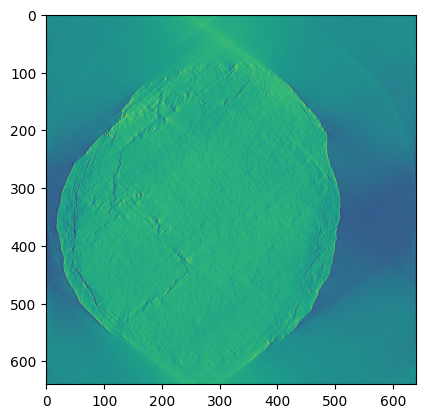

In [6]:
plt.imshow(ds._volumes[0][0])

In [5]:
# ── Instantiate dataset ────────────────────────────────────────────────────
# Pick which slice sources to include: axis0 (axial), axis1 (coronal), axis2 (sagittal), and rand (random plane).
SLICE_TYPES = ("axis0", "axis1","axis2", "rand")

ds = MissingConeDataset(
    data_path=DATA_PATH,
    cone_width_deg=CONE_WIDTH_DEG,
    augment=False,
    # normalize_range=(norm_min, norm_max),
    apply_circle_masking=True,
    gamma=GAMMA_CORRECTION_DEG,
    slice_types=SLICE_TYPES,
)
print(ds)

carved_x0, x0, beta0, alpha0, slice_type0 = ds[50]

print(
    f"\nFirst item  carved_x={carved_x0.shape}  x={x0.shape}  "
    f"beta={beta0}°  alpha={alpha0}°  slice_type={slice_type0}"
)
carved_x0, x0

NpyVolumeSliceDataset: loaded norm from sidecar  norm_min=-0.001071, norm_max=0.003126
MissingConeDataset(files=1, total_slices=2360 (axis0=540, axis1=640, axis2=640, rand=540), image_size=(640, 640), cone_width_deg=72.0, gamma=-6.0, slice_types=['axis0', 'axis1', 'axis2', 'rand'], norm=[-0.001071, 0.003126], augment=False)

First item  carved_x=torch.Size([640, 640])  x=torch.Size([640, 640])  beta=0.0°  alpha=105°  slice_type=axis0


(tensor[640, 640] n=409600 (1.6Mb) x∈[-0.297, 1.424] μ=0.451 σ=0.289,
 tensor[640, 640] n=409600 (1.6Mb) x∈[-0.350, 1.384] μ=0.483 σ=0.331)

In [5]:
def fft_log_magnitude(img: torch.Tensor) -> np.ndarray:
    """Return log1p of the 2-D FFT magnitude, fftshift-ed, as a numpy array."""
    F = torch.fft.fftshift(torch.fft.fft2(img.float()))
    return torch.log1p(F.abs()).numpy()


def plot_fft_with_beta(ax, fft_mag: np.ndarray, beta_deg: float, cone_deg: float):
    """Overlay a double-headed arrow for the carved-cone direction on a FFT image."""
    H, W = fft_mag.shape
    cx, cy = W / 2, H / 2
    arm = min(H, W) * 0.42

    ax.imshow(fft_mag, cmap='hot', origin='upper')
    ax.set_title(f'log|FFT(carved_x)|  β={beta_deg}°', fontsize=9)
    ax.axis('off')

    rad = np.deg2rad(beta_deg)
    dx =  np.cos(rad)   # col direction
    dy = -np.sin(rad)   # row direction (image y is flipped vs math y)

    # draw both Friedel arms
    for sign in (+1, -1):
        ax.annotate(
            '',
            xy=(cx + sign * dx * arm, cy + sign * dy * arm),
            xytext=(cx, cy),
            arrowprops=dict(arrowstyle='->', color='cyan', lw=2.0, mutation_scale=14),
        )
    # cone half-width dashed edges
    half = cone_deg / 2
    for sign in (+1, -1):
        for offset in (-half, +half):
            r_off = np.deg2rad(beta_deg + sign * offset)
            ax.plot(
                [cx, cx + sign * np.cos(r_off) * arm * 0.85],
                [cy, cy - sign * np.sin(r_off) * arm * 0.85],
                color='deepskyblue', lw=0.8, ls='--', alpha=0.7,
            )

print("Helper functions defined ✓")

Helper functions defined ✓


/tmp/ipykernel_82404/805167101.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


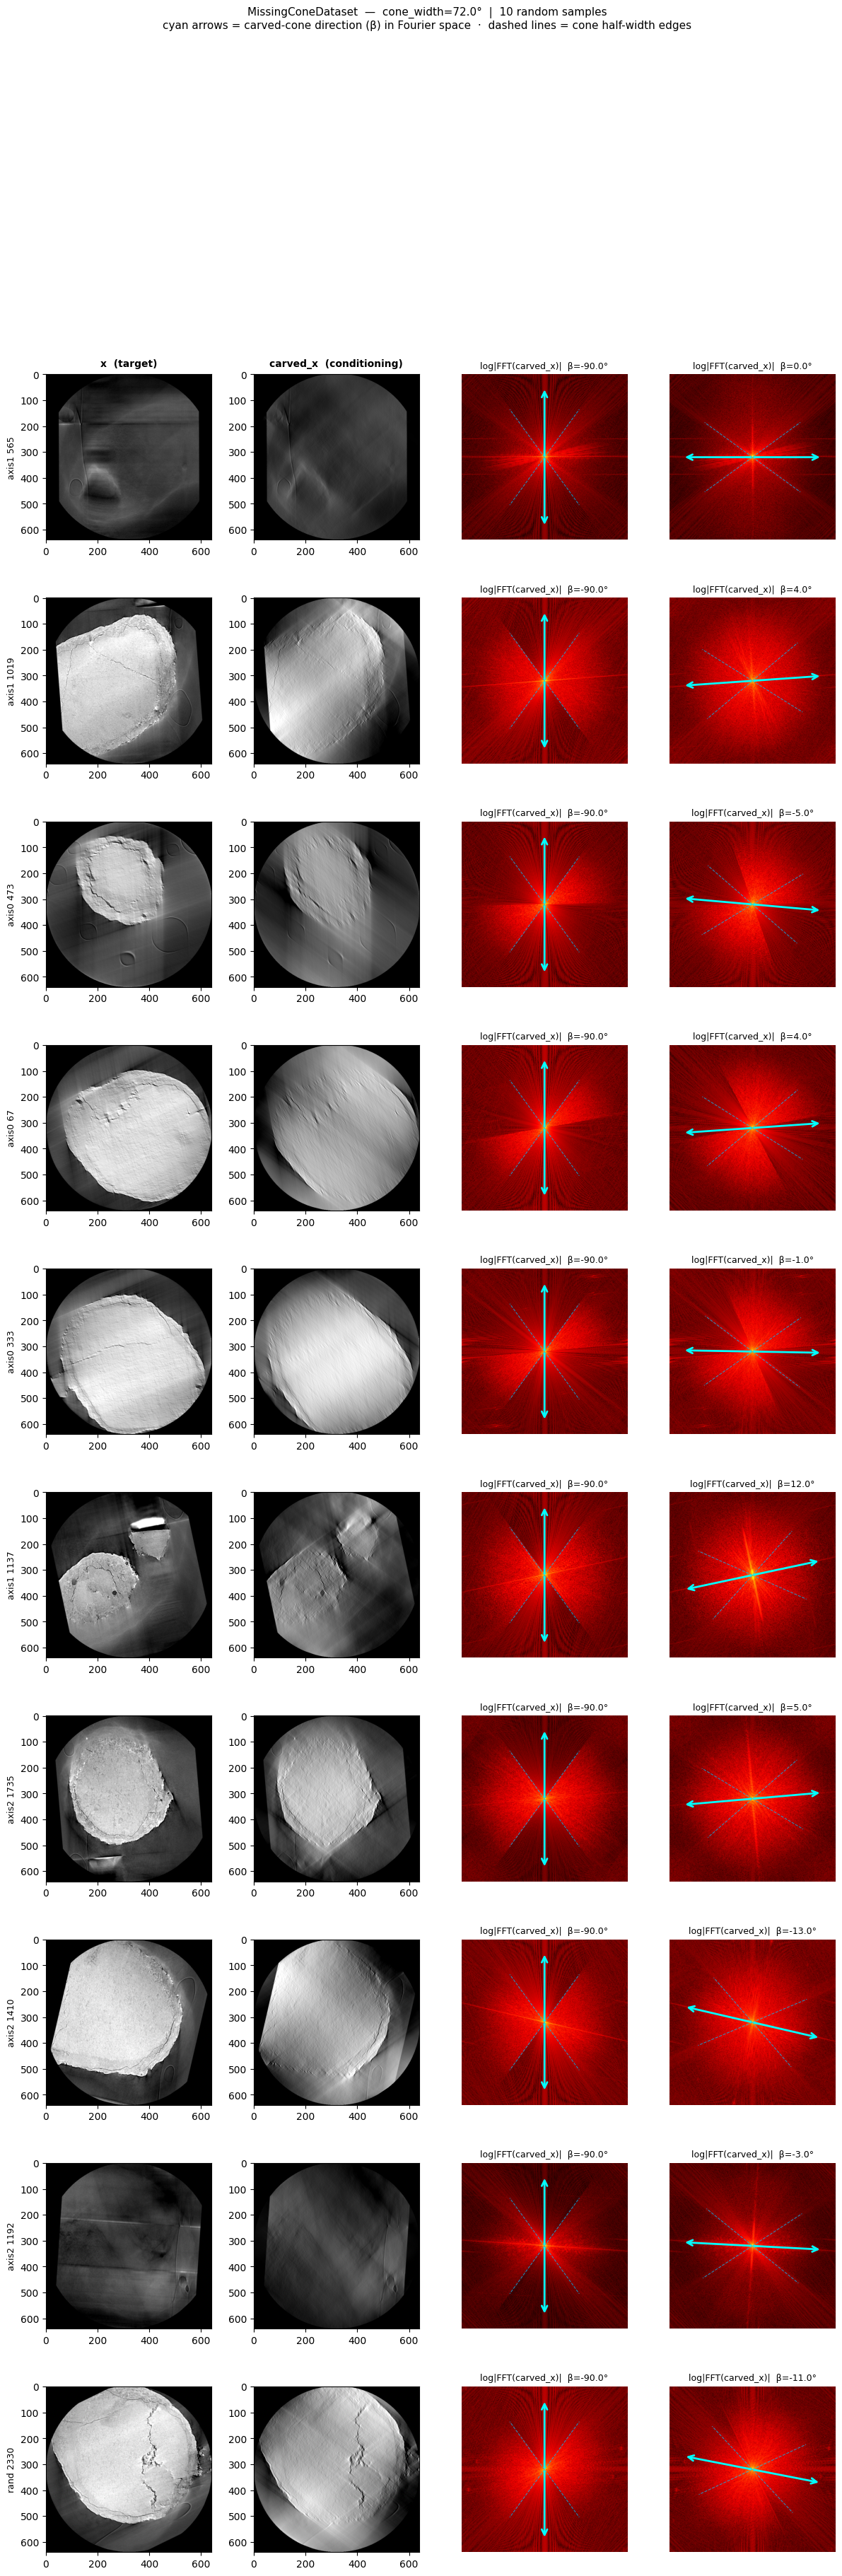

In [6]:
# torch.manual_seed(SEED)
indices = torch.randperm(len(ds))[:N_SAMPLES].tolist()

fig, axes = plt.subplots(N_SAMPLES, 4, figsize=(15, 4 * N_SAMPLES),
                         gridspec_kw={'wspace': 0.05, 'hspace': 0.35})
if N_SAMPLES == 1:
    axes = axes[np.newaxis, :]

for j, title in enumerate(['x  (target)', 'carved_x  (conditioning)', 'log|FFT(carved_x)|  + β arrow']):
    axes[0, j].set_title(title, fontsize=10, fontweight='bold', pad=8)

for row, idx in enumerate(indices):
    carved_x, x, beta_int, alpha_int, slice_type = ds[idx]
    beta_int -= 90
    alpha_int -= 90

    vmin, vmax = norm_min, norm_max

    axes[row, 0].imshow(denormalize_fn(x).numpy(), cmap='gray', vmin=vmin, vmax=vmax)
    axes[row, 0].set_ylabel(f'{slice_type} {idx}', fontsize=9)
    # axes[row, 0].axis('off')

    axes[row, 1].imshow(denormalize_fn(carved_x).numpy(), cmap='gray', vmin=vmin, vmax=vmax)
    # axes[row, 1].axis('off')

    plot_fft_with_beta(axes[row, 2], fft_log_magnitude(carved_x), float(beta_int), CONE_WIDTH_DEG)

    plot_fft_with_beta(axes[row, 3], fft_log_magnitude(x), float(alpha_int), CONE_WIDTH_DEG)

plt.suptitle(
    f'MissingConeDataset  —  cone_width={CONE_WIDTH_DEG}°  |  {N_SAMPLES} random samples\n'
    'cyan arrows = carved-cone direction (β) in Fourier space  ·  dashed lines = cone half-width edges',
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.show()

In [ ]:
# ── Per-sample stats ──────────────────────────────────────────────────────
print(f"{'idx':>6}  {'beta°':>6}  {'x range':>22}  {'carved range':>22}  {'|x-carved| mean':>18}")
print("─" * 82)
for idx in indices:
    carved_x, x, beta_int, alpha_int, slice_type = ds[idx]
    diff_mean = (x - carved_x).abs().mean().item()
    print(
        f"{idx:>6d}  {slice_type:>6s}  {int(beta_int):>6d}  {alpha_int:>6d}  "
        f"[{x.min():.4f}, {x.max():.4f}]  "
        f"[{carved_x.min():.4f}, {carved_x.max():.4f}]  "

        f"{diff_mean:>18.6f}"    )

In [ ]:
# ── Project paths ─────────────────────────────────────────────────────────
project_root = Path('/myhome/sdate')
sys.path.insert(0, str(project_root))
sys.path.insert(0, '/myhome/astra-torch')
sys.path.insert(0, '/myhome/chip-project')

# ── Diffusion model / pipeline ────────────────────────────────────────────
from diffusers.models import UNet2DModel
from ladiff.schedulers.scheduling_ddim import GuidedDDIMScheduler
from ladiff.schedulers.pipeline_ddim import DDIMPipeline

CHECKPOINT_PATH = project_root / 'checkpoints' / f'ddpm_ladiff_cond_ladiff_f{FILE_IDX}.pt'
# CHECKPOINT_PATH = project_root / 'checkpoints' / f'ddpm_ladiff_cond_ladiff_neuron.pt'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

channels = (64, 64, 128, 128, 256, 256)
model = UNet2DModel(
    sample_size=carved_x.shape[0],   # slices are (SLICE_H, SLICE_W); model expects square → use W
    in_channels=2,
    out_channels=1,
    layers_per_block=2,
    block_out_channels=channels,
    down_block_types=(
        "DownBlock2D", "DownBlock2D", "DownBlock2D",
        "DownBlock2D", "AttnDownBlock2D", "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D", "AttnUpBlock2D", "UpBlock2D",
        "UpBlock2D", "UpBlock2D", "UpBlock2D",
    ),
    class_embed_type="timestep"
).to(device)

ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

print(f"Model loaded from {CHECKPOINT_PATH}")
print(f"  Parameters : {sum(p.numel() for p in model.parameters()):,}")
print(f"  in/out channels: 1 / 1  (single 2-D slice)")

In [ ]:
import random
carved_x, x, beta_int, alpha_int, slice_type = ds[random.randint(0, len(ds)-1)]

NUM_INFERENCE_STEPS = 50
scheduler = GuidedDDIMScheduler(1000)
scheduler.set_timesteps(NUM_INFERENCE_STEPS)
timestep = 800
x_t = scheduler.add_noise(x, torch.randn_like(carved_x), timesteps=torch.tensor([timestep])).to(device)
with torch.no_grad():
    model_input = torch.stack([x_t, carved_x.to(device)], dim=0).to(device)  # (2, H, W)
    beta = torch.LongTensor([0.]).to(device)

    noise_pred = model(model_input.unsqueeze(0), timestep=torch.tensor([timestep]).to(device), class_labels=beta, return_dict=False)[0].squeeze()  # (H, W)
    x_0_pred = scheduler.step(noise_pred, timestep=timestep, sample=x_t)['pred_original_sample']  # (H, W)
    diffusion_pred = x_0_pred

x_np = x.detach().cpu().numpy()
carved_np = carved_x.detach().cpu().numpy()
pred_np = diffusion_pred.detach().cpu().numpy()


fig, axes = plt.subplots(1, 3, figsize=(12, 4), gridspec_kw={'wspace': 0.05})
for ax, img, title in zip(
    axes,
    [x_np, carved_np, pred_np],
    ['x (target)', 'carved_x (conditioning)', 'diffusion_pred'],
):
    ax.imshow(img, cmap='gray', vmin=norm_min, vmax=norm_max)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
torch.cuda.empty_cache()
NUM_INFERENCE_STEPS = 50

noise_scheduler = GuidedDDIMScheduler(
    num_train_timesteps=1000,
    guidance_function=lambda x, t:x,
)

pipeline = DDIMPipeline(
    unet=model.to(device),
    scheduler=noise_scheduler,
    fdk_prior=x.unsqueeze(0).clone().to(device),
    normalize_fn=lambda x:x,
    denormalize_fn=lambda x:x,
    slice_batch_size=32,
)

result = pipeline.truncated_pipeline(
    initial_guess=carved_x0.unsqueeze(0).to(device),                   # start from the guided reconstruction (can also start from zeros or FBP)
    start_step=int(.2 * NUM_INFERENCE_STEPS),
    num_inference_steps=NUM_INFERENCE_STEPS,
    use_clipped_model_output=True
)
diffusion_recon = result.images.squeeze(0)  # (H, W)

print(f"Guided DDIM reconstruction done")
print(f"  shape: {diffusion_recon.shape}")
print(f"  range: [{diffusion_recon.min():.4f}, {diffusion_recon.max():.4f}]")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), gridspec_kw={'wspace': 0.05})
for ax, img, title in zip(
    axes,
    [x_np, carved_np, diffusion_recon.cpu().numpy()],
    ['x (target)', 'carved_x (conditioning)', 'diffusion_pred'],
):
    ax.imshow(img, cmap='gray', vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()